# Train a TAM RNN from scratch

A small-scale demo of the supervised pipeline: ~2 minutes on CPU. The shipped reference model used the same recipe at full scale (64×64 input, 2048 hidden, 1000 epochs — see `checkpoints/MANIFEST.md`).

In [1]:
from pathlib import Path
import tempfile

import torch

import illusion_rnn as ir

torch.manual_seed(0)
env = ir.make_env("tam", box_shape="square", variant="standard",
                  stim_ori="horizontal", img_size=32)
env.seed(0)
dataset = ir.make_dataset(env, batch_size=8, seq_len=27)
model = ir.RNNNet(input_size=32 * 32, hidden_size=128, output_size=6, dt=50)
sum(p.numel() for p in model.parameters())

148486

`seq_len=27` packs three 9-step trials per sequence; the loss is cross-entropy over every timestep (fixation steps included).

In [2]:
history = ir.train(model, dataset, n_epochs=300, lr=1e-3,
                   device="cpu", log_every=50)

epoch 50/300  loss 0.2547  acc 1.000


epoch 100/300  loss 0.0876  acc 0.995


epoch 150/300  loss 0.0320  acc 1.000


epoch 200/300  loss 0.0161  acc 1.000


epoch 250/300  loss 0.0103  acc 1.000


epoch 300/300  loss 0.0064  acc 1.000


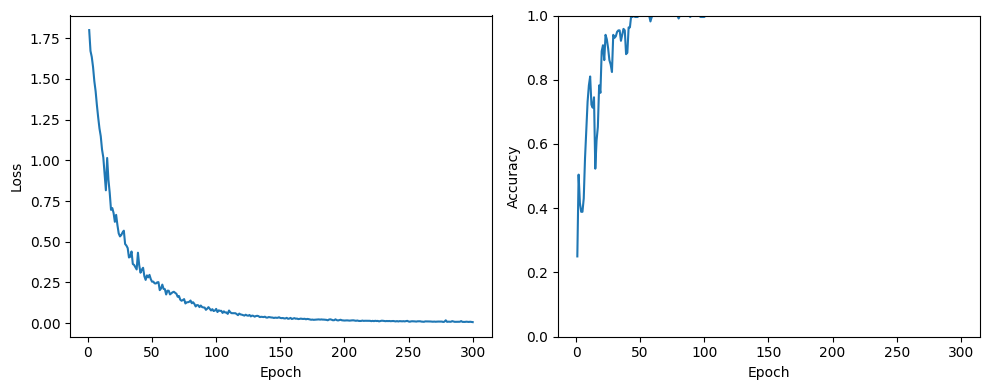

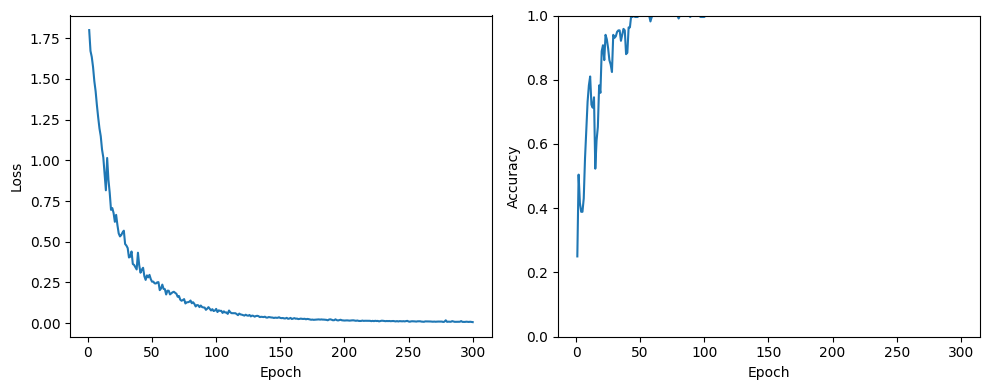

In [3]:
ir.plot_training_curves(history)

## Save, reload, evaluate

State dicts round-trip through `ir.load_rnn`, which infers the architecture from the weights.

In [4]:
path = Path(tempfile.mkdtemp()) / "demo_rnn.pt"
torch.save(model.state_dict(), path)
reloaded = ir.load_rnn(path)

test_env = ir.make_env("tam", box_shape="square", variant="standard",
                       stim_ori="horizontal", img_size=32)
test_env.seed(99)
result = ir.evaluate(reloaded, test_env, n_trials=200, device="cpu")
print(f"accuracy on the trained condition: {result.accuracy:.3f}")

accuracy on the trained condition: 1.000


## Does it transfer to shapes it never saw?

In [5]:
for shape in ("circle", "triangle"):
    e = ir.make_env("tam", box_shape=shape, variant="standard",
                    stim_ori="horizontal", img_size=32)
    e.seed(99)
    acc = ir.evaluate(reloaded, e, n_trials=100, device="cpu").accuracy
    print(f"{shape:9s} {acc:.3f}")

circle    1.000


triangle  0.740


This is deliberately tiny. Scale `hidden_size`, `img_size`, `n_epochs`, and the number of datasets (pass a list to `ir.train`) for real experiments; add `sigma=` to the env for noisy frames, or `encoder=` to train on CNN features instead of pixels.